# Datathon Fase 5 — Case Passos Mágicos
## Notebook 1 · Limpeza, análise exploratória e respostas às perguntas de negócio

**POSTECH Data Analytics — FIAP**

Integrantes: Guilherme Cutrim Batista (RM 369505) · João Victor Castro Rodrigues (RM 369462) · João Victor Gomes Dominici (RM 370163) · Luis Henrique Carvalho Shikasho (RM 368421) · Vítor Francisco Pirani Silva (RM 36916)

---

**Base:** PEDE (Pesquisa Extensiva do Desenvolvimento Educacional) 2022, 2023 e 2024 — três abas com 860, 1.014 e 1.156 alunos.

**Indicadores (0 a 10) que compõem o INDE:**

| Dimensão | Indicador | O que mede |
|---|---|---|
| Acadêmica | **IAN** | Adequação ao nível (10 = em fase · 5 = defasagem moderada · 2,5 = severa) |
| Acadêmica | **IDA** | Desempenho acadêmico (média Mat/Port/Ing) |
| Acadêmica | **IEG** | Engajamento (lições, atividades, voluntariado) |
| Psicossocial | **IAA** | Autoavaliação do aluno |
| Psicossocial | **IPS** | Avaliação psicossocial (psicólogos) |
| Psicopedagógica | **IPP** | Avaliação psicopedagógica (pedagogos/professores) |
| Psicopedagógica | **IPV** | Ponto de virada |

`INDE (fases 0-7) = 0,1·IAN + 0,2·IDA + 0,2·IEG + 0,1·IAA + 0,1·IPS + 0,1·IPP + 0,2·IPV`

**Pedras (faixas de INDE):** Quartzo 2,405–5,506 · Ágata 5,506–6,868 · Ametista 6,868–8,230 · Topázio 8,230–9,294

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import data_prep

FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 60); pd.set_option("display.precision", 2)

AZUL, LARANJA, AMARELO, CINZA = "#16508A", "#F58634", "#F7B32B", "#7A7A7A"
PEDRA_ORDEM = ["Quartzo", "Ágata", "Ametista", "Topázio"]
PEDRA_COR = {"Quartzo": "#9E8E7E", "Ágata": "#F58634", "Ametista": "#7B4FA0", "Topázio": "#F7B32B"}
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})

def salvar(nome):
    plt.tight_layout(); plt.savefig(FIG / f"{nome}.png", dpi=150, bbox_inches="tight"); plt.show()

## 1. Entendendo a base bruta e seus problemas de qualidade

In [2]:
xls = pd.ExcelFile(data_prep.RAW)
for aba in xls.sheet_names:
    d = xls.parse(aba)
    print(f"{aba}: {d.shape[0]} linhas x {d.shape[1]} colunas")

PEDE2022: 860 linhas x 42 colunas


PEDE2023: 1014 linhas x 48 colunas


PEDE2024: 1156 linhas x 50 colunas


In [3]:
raw24 = xls.parse("PEDE2024"); raw23 = xls.parse("PEDE2023")
print("Fase 2024 (mistura fase+turma):", raw24["Fase"].astype(str).unique()[:15])
print("Idade 2023 (parte veio como data):", raw23["Idade"].map(type).value_counts().to_dict())
print("Pedra 2024:", raw24["Pedra 2024"].value_counts(dropna=False).to_dict())
print("INDE 2024 com texto:", raw24["INDE 2024"][raw24["INDE 2024"].map(type) == str].unique())
print("IAA = 0 em 2023:", (raw23["IAA"] == 0).sum())

Fase 2024 (mistura fase+turma): <ArrowStringArray>
['ALFA',   '1A',   '1B',   '1C',   '1D',   '1E',   '1G',   '1H',   '1J',
   '1K',   '1L',   '1M',   '1N',   '1P',   '1R']
Length: 15, dtype: str
Idade 2023 (parte veio como data): {<class 'int'>: 615, <class 'datetime.datetime'>: 399}
Pedra 2024: {'Ametista': 391, 'Topázio': 326, 'Agata': 225, 'Quartzo': 112, nan: 64, 'INCLUIR': 38}
INDE 2024 com texto: ['INCLUIR']
IAA = 0 em 2023: 190


**Problemas encontrados e tratamento aplicado (`src/data_prep.py`):**

| Problema | Tratamento |
|---|---|
| Nomes de colunas diferentes em cada aba (`Defas`/`Defasagem`, `Matem`/`Mat`…) | Dicionário `COLMAP` → nomes únicos |
| `Fase` 2024 mistura fase e turma (`"4M"`, `"ALFA"`, `9`) e 2023 vem como `"FASE 3"` | Extração do dígito; ALFA = 0 |
| `Idade` 2023 parcialmente em formato data (`1900-01-11` = 11 anos) | Conversão pelo dia |
| Gênero `Menina/Menino` (2022) vs `Feminino/Masculino` | Padronização |
| Pedra `Agata` sem acento e `INCLUIR` (2024) | Padronização; `INCLUIR` → pedra derivada do INDE ou nulo |
| Alunos ingressantes sem nenhuma avaliação (IEG = 0 e demais nulos) | Flag `SEM_AVALIACAO`, excluídos das médias |
| IAA = 0 (190 casos em 2023) — impossível pela regra do questionário | Tratado como não respondido |
| IPP não existe em 2022 | Mantido nulo; análises de IPP usam 2023-2024 |
| Instituição de ensino com 8+ categorias | Agrupada em Pública / Privada-Bolsa / Outros |

Validação: `DEFASAGEM = FASE − FASE_IDEAL` bate em 100% (2022-2023) e 99,8% (2024) dos registros.

In [4]:
data_prep.main()
L_all = pd.read_csv(ROOT / "data/processed/pede_long.csv")
P = pd.read_csv(ROOT / "data/processed/pares_t_t1.csv")
L = L_all[~L_all["SEM_AVALIACAO"]].copy()          # só alunos avaliados
chk = L_all.dropna(subset=["FASE", "FASE_IDEAL"])
print("Consistência D = Fase - Fase ideal:", ((chk.FASE - chk.FASE_IDEAL) == chk.DEFASAGEM).groupby(chk.ANO).mean().round(4).to_dict())
print("Alunos por ano:", L_all.ANO.value_counts().sort_index().to_dict())
print("Pares aluno t -> t+1:", P.ANO.value_counts().sort_index().to_dict())
L.head()

pede_long.csv  -> (3030, 30)
pares_t_t1.csv -> (1365, 41)
Consistência D = Fase - Fase ideal: {2022: 1.0, 2023: 1.0, 2024: 0.9983}
Alunos por ano: {2022: 860, 2023: 1014, 2024: 1156}
Pares aluno t -> t+1: {2022: 600, 2023: 765}


,RA,ANO,FASE,TURMA,IDADE,GENERO,ANO_INGRESSO,ANOS_NA_PM,INSTITUICAO,INSTITUICAO_GRUPO,PEDRA,INDE,IAN,IDA,IEG,IAA,IPS,IPP,IPV,MAT,POR,ING,FASE_IDEAL,DEFASAGEM,CLASSE_DEFASAGEM,EM_DEFASAGEM,PONTO_VIRADA,N_AVALIACOES,SEM_AVALIACAO,IAA_ZERADO
0,RA-1,2022,7.0,A,19.0,Feminino,2016,6,Escola Pública,Pública,Quartzo,5.78,5.0,4.0,4.1,8.3,5.6,NaN,7.28,2.7,3.5,6.0,8.0,-1,Moderada,1,0.0,4.0,False,0
1,RA-2,2022,7.0,A,17.0,Feminino,2017,5,Rede Decisão,Privada/Bolsa,Ametista,7.05,10.0,6.8,5.2,8.8,6.3,NaN,6.78,6.3,4.5,9.7,7.0,0,Em fase,0,0.0,4.0,False,0
2,RA-3,2022,7.0,A,17.0,Feminino,2016,6,Rede Decisão,Privada/Bolsa,Ágata,6.59,10.0,5.6,7.9,NaN,5.6,NaN,7.56,5.8,4.0,6.9,7.0,0,Em fase,0,0.0,4.0,False,1
3,RA-4,2022,7.0,A,17.0,Masculino,2017,5,Rede Decisão,Privada/Bolsa,Quartzo,5.95,10.0,5.0,4.5,8.8,5.6,NaN,5.28,2.8,3.5,8.7,7.0,0,Em fase,0,0.0,4.0,False,0
4,RA-5,2022,7.0,A,17.0,Feminino,2016,6,Rede Decisão,Privada/Bolsa,Ametista,7.43,10.0,5.2,8.6,7.9,5.6,NaN,7.39,7.0,2.9,5.7,7.0,0,Em fase,0,0.0,4.0,False,0


## Pergunta 1 — Adequação ao nível (IAN)
*Qual é o perfil geral de defasagem dos alunos e como ele evolui?*

Classificação oficial (Tabela 41 do PEDE): **D ≥ 0 em fase · −2 ≤ D < 0 moderada · D < −2 severa**.

CLASSE_DEFASAGEM,Em fase,Moderada,Severa,Em fase %,Moderada %,Severa %
ANO,,,,,,
2022,259,573,28,30.1,66.6,3.3
2023,462,538,14,45.6,53.1,1.4
2024,622,531,3,53.8,45.9,0.3


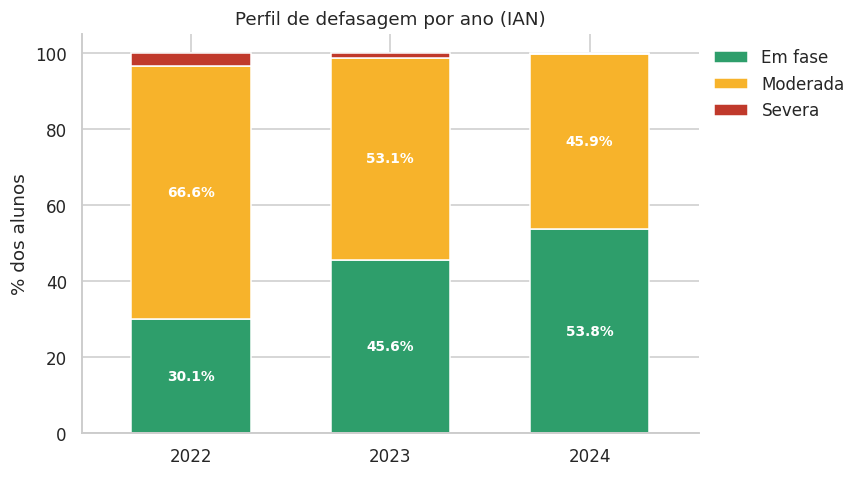

In [5]:
tab = pd.crosstab(L_all.ANO, L_all.CLASSE_DEFASAGEM)[["Em fase", "Moderada", "Severa"]]
pct = (tab.div(tab.sum(1), axis=0) * 100).round(1)
display(tab.join(pct, rsuffix=" %"))

ax = pct.plot(kind="bar", stacked=True, color=["#2E9E6B", AMARELO, "#C0392B"], figsize=(8, 4.5), width=0.6)
for c in ax.containers:
    ax.bar_label(c, labels=[f"{v:.1f}%" if v >= 5 else "" for v in c.datavalues], label_type="center", fontsize=9, color="white", fontweight="bold")
ax.set(title="Perfil de defasagem por ano (IAN)", xlabel="", ylabel="% dos alunos"); ax.legend(bbox_to_anchor=(1, 1), frameon=False)
plt.xticks(rotation=0); salvar("q1_defasagem_por_ano")

In [6]:
# Mesmo aluno ao longo do tempo: como a defasagem muda de um ano para o outro?
print(pd.crosstab(P.DEFASAGEM, P.DEFASAGEM_T1, margins=True))
print("\nIAN médio por ano:", L_all.groupby("ANO").IAN.mean().round(2).to_dict())
print("Defasagem média por ano:", L_all.groupby("ANO").DEFASAGEM.mean().round(2).to_dict())

DEFASAGEM_T1  -4  -3   -2   -1    0    1   2   All
DEFASAGEM                                         
-4             1   1    0    0    0    0   0     2
-3             0   3    9    0    0    2   0    14
-2             0   5   76  108   11    0   0   200
-1             0   0   63  264  257    3   3   590
0              0   0    1  142  272   87  11   513
1              0   0    0    1   17   14   6    38
2              0   0    0    0    0    7   1     8
All            1   9  149  515  557  113  21  1365

IAN médio por ano: {2022: 6.42, 2023: 7.24, 2024: 7.68}
Defasagem média por ano: {2022: -0.94, 2023: -0.65, 2024: -0.41}


**Resposta:** a defasagem é a regra, mas está diminuindo de forma consistente.
- Em **2022, 70% dos alunos estavam defasados** (66,6% moderada + 3,3% severa). Em **2024 esse número caiu para 46%** (45,9% + 0,3%).
- Alunos **em fase** passaram de 30% → 46% → **54%**; a defasagem severa praticamente desapareceu (3,3% → 0,3%).
- O IAN médio subiu de 6,4 para 7,7 e a defasagem média foi de −0,94 para −0,41 fase.
- Ponto de atenção: a matriz de transição mostra que **142 alunos "em fase" (D = 0) passaram para D = −1** no ano seguinte — são alunos que não avançaram de fase num ano em que a idade exigia avanço. É exatamente esse grupo que o modelo preditivo (Pergunta 9) busca antecipar.

## Pergunta 2 — Desempenho acadêmico (IDA)
*O IDA médio está melhorando, estagnado ou caindo ao longo das fases e anos?*

IDA médio por ano: {2022: 6.09, 2023: 6.66, 2024: 6.35}
       MAT   POR   ING
ANO                   
2022  5.81  6.32  5.88
2023  6.41  6.82  6.20
2024  6.23  6.18  6.60


ANO,2022,2023,2024
FASE,,,
0.0,7.14,7.42,7.32
1.0,6.46,6.81,6.79
2.0,5.41,6.74,6.25
3.0,5.14,5.75,5.35
4.0,6.05,6.00,5.88
5.0,5.87,5.90,6.45
6.0,6.69,6.81,7.23
7.0,5.25,7.81,5.81


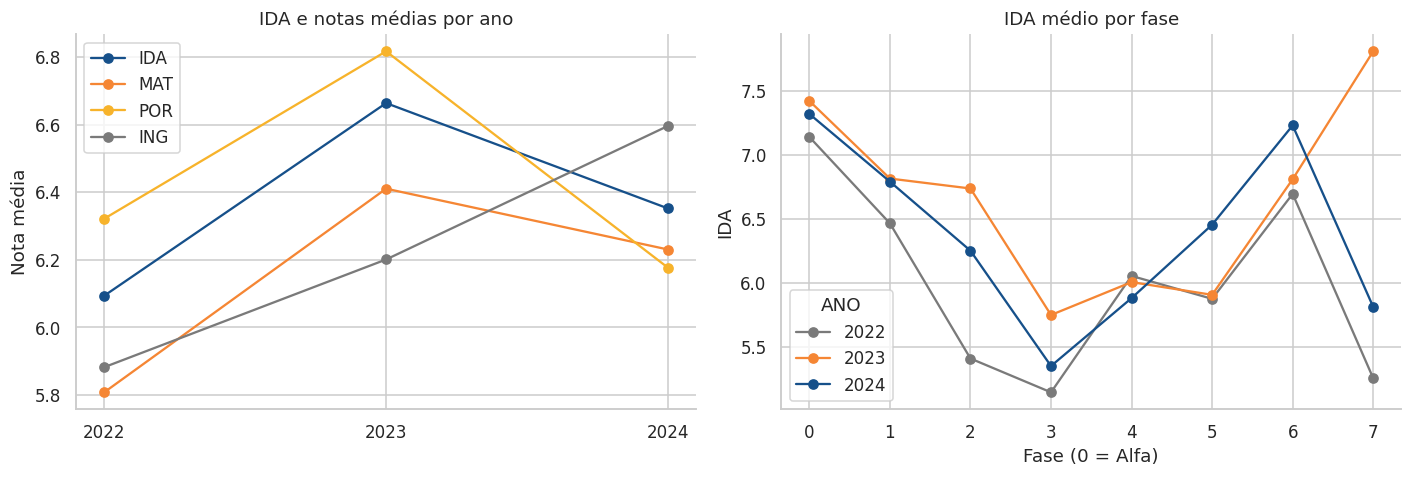

In [7]:
print("IDA médio por ano:", L.groupby("ANO").IDA.mean().round(2).to_dict())
print(L.groupby("ANO")[["MAT", "POR", "ING"]].mean().round(2))
piv = L[L.FASE <= 7].pivot_table(index="FASE", columns="ANO", values="IDA", aggfunc="mean")
display(piv.round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
L.groupby("ANO")[["IDA", "MAT", "POR", "ING"]].mean().plot(marker="o", ax=ax[0], color=[AZUL, LARANJA, AMARELO, CINZA])
ax[0].set(title="IDA e notas médias por ano", ylabel="Nota média", xlabel=""); ax[0].set_xticks([2022, 2023, 2024])
piv.plot(marker="o", ax=ax[1], color=[CINZA, LARANJA, AZUL])
ax[1].set(title="IDA médio por fase", xlabel="Fase (0 = Alfa)", ylabel="IDA")
salvar("q2_ida_ano_fase")

**Resposta:** o desempenho acadêmico está **oscilando, sem tendência clara de melhora**.
- IDA médio: **6,09 (2022) → 6,66 (2023) → 6,35 (2024)**. Houve ganho em 2023 que não se sustentou em 2024 (queda puxada por Português: 6,82 → 6,18).
- Por fase, o padrão é estável nos três anos: o IDA **cai da Alfa (≈7,3) até as Fases 3-4 (≈5,4–6,0)** e volta a subir no Ensino Médio. As **Fases 2 a 4 (5º ao 9º ano)** são o "vale" do desempenho — onde a exigência de conteúdo cresce.
- Mensagem: a redução da defasagem (P1) não veio acompanhada de ganho acadêmico proporcional; o reforço de Matemática e Português nas Fases 2-4 é prioridade.

## Pergunta 3 — Engajamento (IEG)
*O IEG tem relação direta com o desempenho (IDA) e o ponto de virada (IPV)?*

,IDA,IPV,INDE
2022,0.56,0.59,0.80
2023,0.46,0.45,0.65
2024,0.54,0.54,0.79


,IDA,IPV,INDE
IEG_QUARTIL,,,
Q1 (menor),4.93,6.71,6.26
Q2,6.27,7.44,7.15
Q3,6.91,7.85,7.64
Q4 (maior),7.46,8.22,8.07


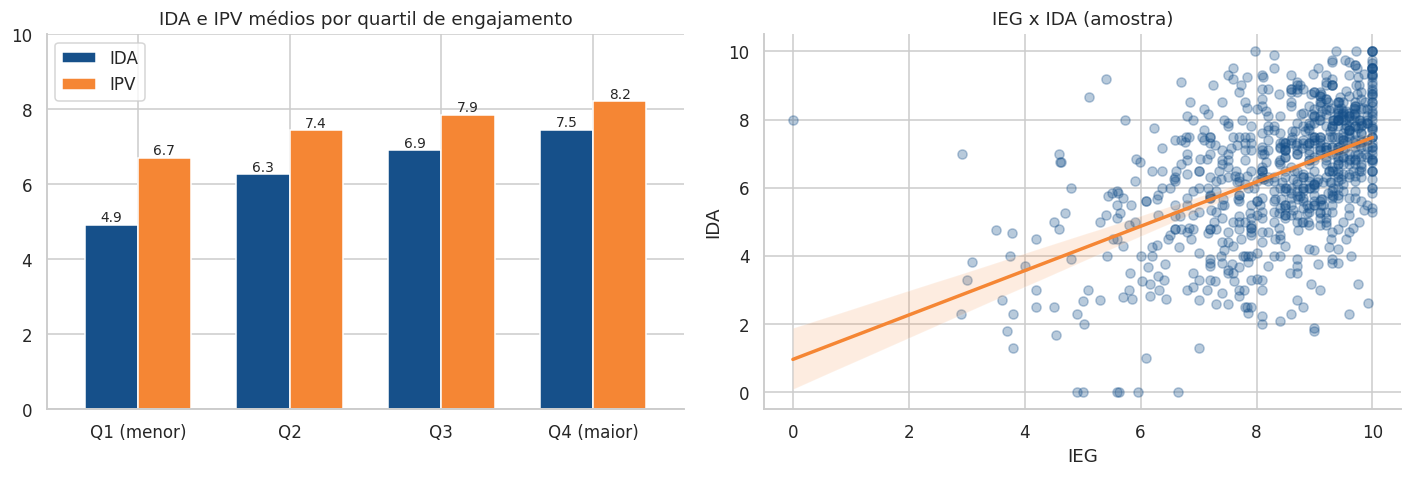

In [8]:
corr = pd.DataFrame({a: g[["IEG", "IDA", "IPV", "INDE"]].corr().loc["IEG", ["IDA", "IPV", "INDE"]] for a, g in L.groupby("ANO")}).T
display(corr.round(2))
L["IEG_QUARTIL"] = pd.qcut(L.IEG, 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])
q = L.groupby("IEG_QUARTIL")[["IDA", "IPV", "INDE"]].mean(); display(q.round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
q[["IDA", "IPV"]].plot(kind="bar", ax=ax[0], color=[AZUL, LARANJA], width=0.7)
for c in ax[0].containers: ax[0].bar_label(c, fmt="%.1f", fontsize=9)
ax[0].set(title="IDA e IPV médios por quartil de engajamento", xlabel="", ylim=(0, 10)); ax[0].tick_params(axis="x", rotation=0)
sns.regplot(data=L.sample(800, random_state=1), x="IEG", y="IDA", ax=ax[1], scatter_kws={"alpha": .3, "color": AZUL}, line_kws={"color": LARANJA})
ax[1].set(title="IEG x IDA (amostra)")
salvar("q3_engajamento")

**Resposta: sim — o engajamento é o indicador comportamental mais associado aos resultados.**
- Correlação IEG × IDA entre **0,46 e 0,56** e IEG × IPV entre **0,45 e 0,59** nos três anos (moderada e positiva, estável).
- Alunos no quartil mais engajado têm **IDA 7,5 vs 4,9** no quartil menos engajado (+2,5 pontos) e **IPV 8,2 vs 6,7**.
- Como o IEG é medido de forma contínua (entregas de lição, atividades), ele funciona como **termômetro precoce**: uma queda de IEG deve disparar ação antes da próxima avaliação de IDA.

## Pergunta 4 — Autoavaliação (IAA)
*As percepções dos alunos sobre si mesmos são coerentes com o desempenho real (IDA) e o engajamento (IEG)?*

,IDA,IEG
2022,0.15,0.18
2023,0.11,0.12
2024,0.15,0.19


,IAA,IDA
IDA_QUARTIL,,
Q1 (menor),8.48,3.72
Q2,8.64,5.95
Q3,8.66,7.25
Q4 (maior),8.90,8.65


Superestimam (IAA - IDA > 2): 47% | Subestimam (< -2): 1%


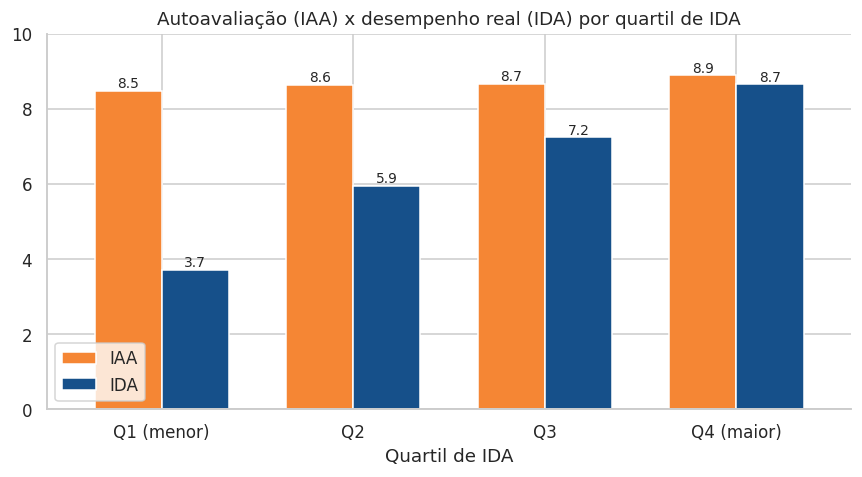

In [9]:
display(pd.DataFrame({a: g[["IAA", "IDA", "IEG"]].corr().loc["IAA", ["IDA", "IEG"]] for a, g in L.groupby("ANO")}).T.round(2))
L["GAP_IAA_IDA"] = L.IAA - L.IDA
L["IDA_QUARTIL"] = pd.qcut(L.IDA, 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])
t = L.groupby("IDA_QUARTIL")[["IAA", "IDA"]].mean(); display(t.round(2))
print(f"Superestimam (IAA - IDA > 2): {(L.GAP_IAA_IDA > 2).mean():.0%} | Subestimam (< -2): {(L.GAP_IAA_IDA < -2).mean():.0%}")

ax = t.plot(kind="bar", color=[LARANJA, AZUL], figsize=(8, 4.5), width=0.7)
for c in ax.containers: ax.bar_label(c, fmt="%.1f", fontsize=9)
ax.set(title="Autoavaliação (IAA) x desempenho real (IDA) por quartil de IDA", xlabel="Quartil de IDA", ylim=(0, 10)); plt.xticks(rotation=0)
salvar("q4_autoavaliacao")

**Resposta: não são coerentes — a autoavaliação é alta e quase "plana".**
- Correlação IAA × IDA de apenas **0,11 a 0,15** e IAA × IEG de **0,12 a 0,19** nos três anos.
- Alunos do quartil de **pior** IDA (média 3,7) se dão **8,5** de autoavaliação; os do **melhor** quartil (IDA 8,7) se dão 8,9 — uma diferença real de 5 pontos vira 0,4 na percepção.
- **Quase metade dos alunos (47%) superestima** o próprio desempenho em mais de 2 pontos; só 1% se subestima.
- Leitura: o IAA reflete autoestima e pertencimento (valor importante para o programa), mas **não é um bom sinal de alerta acadêmico**. Sugestão: devolutivas individuais comparando IAA × IDA para calibrar a percepção.

## Pergunta 5 — Aspectos psicossociais (IPS)
*Há padrões psicossociais que antecedem quedas de desempenho ou engajamento?*

Usamos os **pares longitudinais** (mesmo aluno em t e t+1) e definimos queda como perda de ≥ 1 ponto no indicador.

,QUEDA_IDA,QUEDA_IEG,n
IPS_FAIXA,,,
Baixo (<5),36.2,32.6,304
Médio (5-7),29.6,22.2,365
Alto (≥7),28.2,18.8,595


Correlação IPS(t) com variação em t+1: {'dIDA': 0.12, 'dIEG': 0.19}


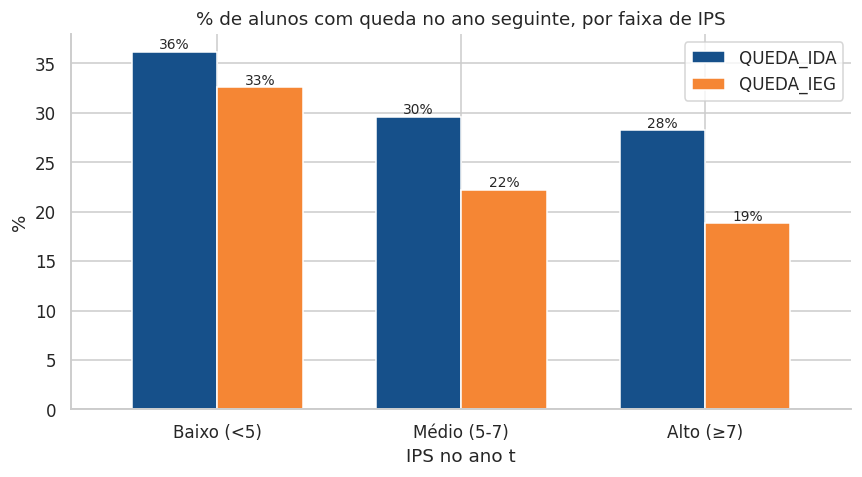

In [10]:
P["QUEDA_IDA"] = ((P.IDA_T1 - P.IDA) <= -1).astype(int)
P["QUEDA_IEG"] = ((P.IEG_T1 - P.IEG) <= -1).astype(int)
Pq = P.dropna(subset=["IPS", "IDA_T1", "IEG_T1"]).copy()
Pq["IPS_FAIXA"] = pd.cut(Pq.IPS, [0, 5, 7, 10.1], labels=["Baixo (<5)", "Médio (5-7)", "Alto (≥7)"], right=False)
r = Pq.groupby("IPS_FAIXA")[["QUEDA_IDA", "QUEDA_IEG"]].mean() * 100
display(r.round(1).join(Pq.IPS_FAIXA.value_counts().rename("n")))
print("Correlação IPS(t) com variação em t+1:", Pq[["IPS"]].join(pd.DataFrame({"dIDA": Pq.IDA_T1 - Pq.IDA, "dIEG": Pq.IEG_T1 - Pq.IEG})).corr().loc["IPS", ["dIDA", "dIEG"]].round(2).to_dict())

ax = r.plot(kind="bar", color=[AZUL, LARANJA], figsize=(8, 4.5), width=0.7)
for c in ax.containers: ax.bar_label(c, fmt="%.0f%%", fontsize=9)
ax.set(title="% de alunos com queda no ano seguinte, por faixa de IPS", xlabel="IPS no ano t", ylabel="%"); plt.xticks(rotation=0)
salvar("q5_ips_quedas")

**Resposta: o sinal existe, mas é fraco — o IPS antecede mais a queda de *engajamento* do que a de notas.**
- Com **IPS baixo (< 5)**, **33%** dos alunos têm queda de engajamento no ano seguinte, contra **19%** com IPS alto (≥ 7). Para notas: 36% vs 28%.
- A correlação IPS(t) × variação do IEG em t+1 é **+0,19** e com a variação do IDA, **+0,12**: sinal real, porém fraco — as quedas de nota dependem mais do contexto acadêmico da fase.
- **Limitação importante:** o IPS mudou de escala entre os anos (em 2023 os valores se concentram em 2,52 / 5,0 / 7,52, média 5,1 vs 6,9 nos outros anos). Recomendamos à Passos Mágicos **padronizar o instrumento psicossocial** para permitir séries históricas confiáveis.
- Encaminhamento prático: IPS baixo + IEG em queda = prioridade para atendimento psicológico.

## Pergunta 6 — Aspectos psicopedagógicos (IPP)
*As avaliações psicopedagógicas confirmam ou contradizem a defasagem do IAN?* (IPP existe apenas em 2023 e 2024)

mean  median  count
ANO  CLASSE_DEFASAGEM                     
2023 Em fase           7.67    7.81    388
     Moderada          7.50    7.50    536
     Severa            6.96    7.58     14
2024 Em fase           7.69    7.71    520
     Moderada          7.41    7.50    531
     Severa            7.26    7.03      3

Correlação IPP x IAN: 0.12
IPP_BAIXO         False  True 
CLASSE_DEFASAGEM              
Em fase            82.9   17.1
Moderada           74.2   25.8
Severa             58.8   41.2


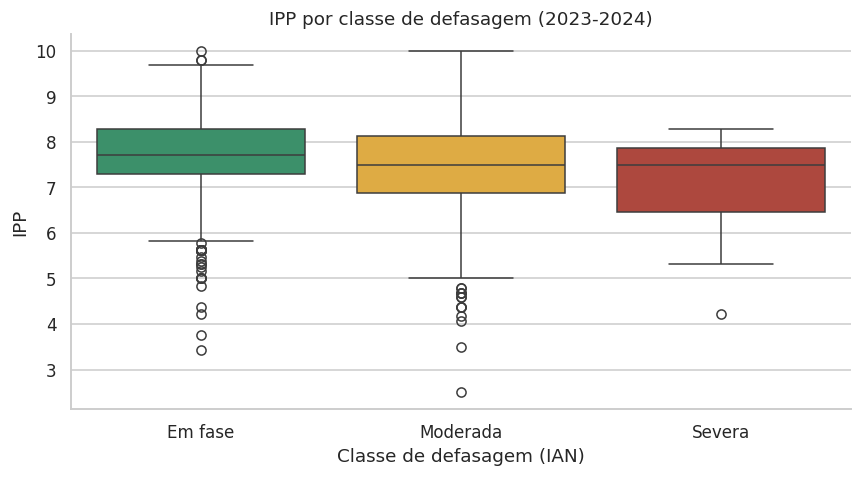

In [11]:
Lp = L[L.ANO >= 2023].dropna(subset=["IPP"])
display(Lp.groupby(["ANO", "CLASSE_DEFASAGEM"]).IPP.agg(["mean", "median", "count"]).round(2))
print("Correlação IPP x IAN:", Lp[["IPP", "IAN"]].corr().iloc[0, 1].round(2))
Lp["IPP_BAIXO"] = Lp.IPP < 7
print((pd.crosstab(Lp.CLASSE_DEFASAGEM, Lp.IPP_BAIXO, normalize="index") * 100).round(1))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=Lp, x="CLASSE_DEFASAGEM", y="IPP", order=["Em fase", "Moderada", "Severa"], palette=["#2E9E6B", AMARELO, "#C0392B"], ax=ax)
ax.set(title="IPP por classe de defasagem (2023-2024)", xlabel="Classe de defasagem (IAN)")
salvar("q6_ipp_ian")

**Resposta: o IPP confirma a *direção* da defasagem, mas discrimina pouco.**
- IPP médio: **em fase 7,7 · moderada 7,4–7,5 · severa 7,0–7,3** — a ordem é a esperada, porém as diferenças são pequenas e a correlação IPP × IAN é só **0,12**.
- IPP abaixo de 7 aparece em **17%** dos alunos em fase, **26%** dos moderados e **41%** dos severos: confirma nos extremos, mas não separa bem os grupos.
- Ou seja, a avaliação psicopedagógica enxerga muitos alunos defasados como "adequados" do ponto de vista de aprendizagem. Isso é coerente com a lógica do programa: o IAN mede **idade × fase**, enquanto o IPP mede **como o aluno aprende** — são complementares, não redundantes.
- Oportunidade: usar a divergência (IAN baixo + IPP alto) para identificar alunos **prontos para avançar de fase**, acelerando a correção da defasagem.

## Pergunta 7 — Ponto de virada (IPV)
*Quais comportamentos mais influenciam o IPV?*

,IDA,IEG,IAA,IPS,IPP
2022,0.62,0.59,0.24,0.21,NaN
2023,0.54,0.45,0.17,0.08,0.52
2024,0.51,0.54,0.15,0.11,0.75


R² = 0.54


,IDA,IEG,IAA,IPS,IPV
PONTO_VIRADA,,,,,
Não atingiu,5.82,7.72,8.61,6.84,7.01
Atingiu PV,7.87,9.01,9.03,7.32,8.86


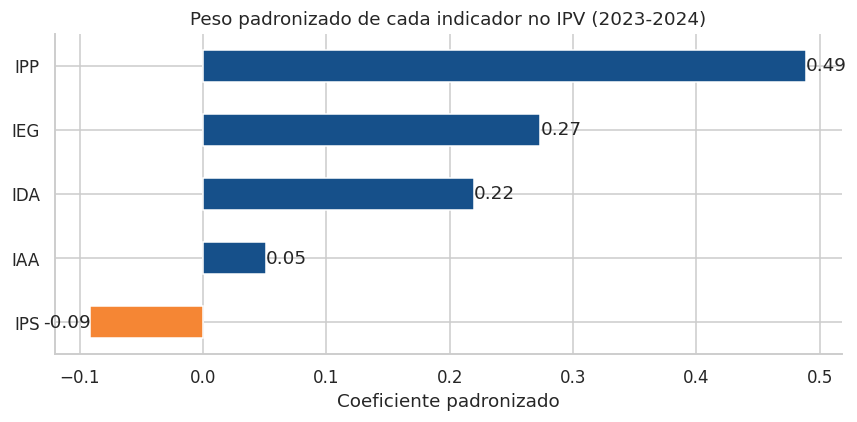

In [12]:
display(pd.DataFrame({a: g[["IPV", "IDA", "IEG", "IAA", "IPS", "IPP"]].corr().loc["IPV", ["IDA", "IEG", "IAA", "IPS", "IPP"]] for a, g in L.groupby("ANO")}).T.round(2))

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
d = L[L.ANO >= 2023].dropna(subset=["IPV", "IDA", "IEG", "IAA", "IPS", "IPP"])
cols = ["IDA", "IEG", "IAA", "IPS", "IPP"]
lr = LinearRegression().fit(StandardScaler().fit_transform(d[cols]), d.IPV)
coef = pd.Series(lr.coef_, index=cols).sort_values()
print(f"R² = {lr.score(StandardScaler().fit_transform(d[cols]), d.IPV):.2f}")

g22 = L[L.ANO == 2022].groupby("PONTO_VIRADA")[["IDA", "IEG", "IAA", "IPS", "IPV"]].mean().rename(index={0: "Não atingiu", 1: "Atingiu PV"})
display(g22.round(2))

ax = coef.plot(kind="barh", color=[LARANJA if v < 0 else AZUL for v in coef], figsize=(8, 4))
ax.bar_label(ax.containers[0], fmt="%.2f"); ax.set(title="Peso padronizado de cada indicador no IPV (2023-2024)", xlabel="Coeficiente padronizado")
salvar("q7_ipv_drivers")

**Resposta: o ponto de virada é puxado por aprendizagem percebida pelos educadores (IPP), engajamento (IEG) e desempenho (IDA).**
- Pesos padronizados (2023-2024, R² = 0,54): **IPP 0,49 · IEG 0,27 · IDA 0,22**; IAA e IPS têm peso quase nulo.
- Em 2022, quem **atingiu o ponto de virada** tinha IEG **9,0 vs 7,7** e IDA **7,9 vs 5,8** de quem não atingiu.
- Tradução em comportamento: **fazer as lições e participar (IEG) + evoluir nas notas (IDA)** é o caminho para a virada; o fator emocional aparece de forma indireta (via engajamento — ver P5).

## Pergunta 8 — Multidimensionalidade
*Quais combinações de IDA + IEG + IPS + IPP elevam mais o INDE?*

Para cada combinação, comparamos o INDE médio dos alunos que estão **acima da mediana em todos** os indicadores da combinação vs o restante (2023-2024).

,Combinação,n alunos,INDE (todos altos),INDE (demais),% Topázio
0,IDA + IEG + IPS + IPP,307,8.42,7.18,81.76
1,IDA + IEG + IPS,357,8.35,7.16,75.07
2,IDA + IEG + IPP,573,8.27,7.01,72.08
3,IEG + IPS + IPP,406,8.27,7.14,69.46
4,IDA + IPS + IPP,438,8.26,7.12,69.63
5,IDA + IEG,675,8.18,6.95,65.19
6,IEG + IPS,501,8.15,7.11,60.28
7,IDA + IPS,544,8.15,7.08,61.03
8,IDA + IPP,788,8.11,6.89,60.41
9,IEG + IPP,784,8.07,6.92,57.27


Peso padronizado no INDE: {'IDA': np.float64(0.45), 'IEG': np.float64(0.39), 'IPS': np.float64(0.23), 'IPP': np.float64(0.21)}


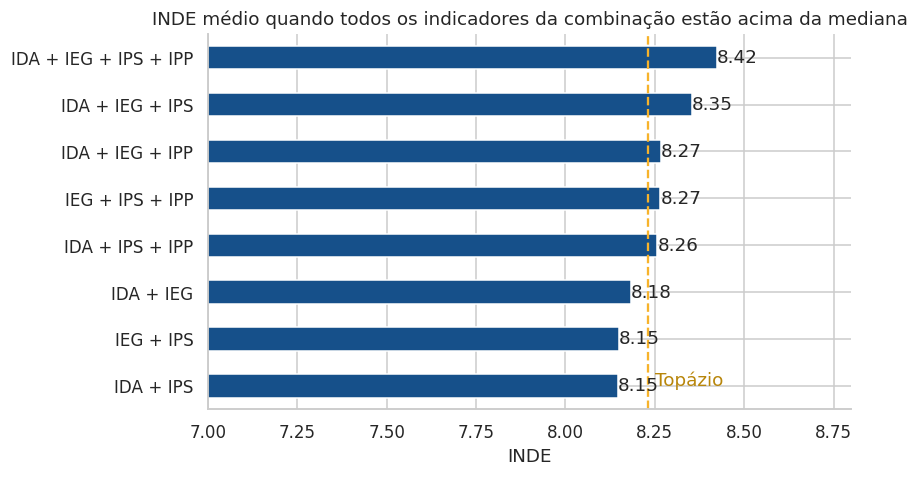

In [13]:
import itertools
d = L[L.ANO >= 2023].dropna(subset=["INDE", "IDA", "IEG", "IPS", "IPP"])
base = ["IDA", "IEG", "IPS", "IPP"]
med = d[base].median()
rows = []
for k in range(1, 5):
    for comb in itertools.combinations(base, k):
        m = np.all([d[c] >= med[c] for c in comb], axis=0)
        rows.append({"Combinação": " + ".join(comb), "n alunos": int(m.sum()), "INDE (todos altos)": d.INDE[m].mean(),
                     "INDE (demais)": d.INDE[~m].mean(), "% Topázio": (d.PEDRA[m] == "Topázio").mean() * 100})
comb = pd.DataFrame(rows).sort_values("INDE (todos altos)", ascending=False).reset_index(drop=True)
display(comb.round(2))

lr = LinearRegression().fit(StandardScaler().fit_transform(d[base]), d.INDE)
print("Peso padronizado no INDE:", dict(zip(base, lr.coef_.round(2))))

top = comb.head(8).iloc[::-1]
ax = top.plot(x="Combinação", y="INDE (todos altos)", kind="barh", color=AZUL, legend=False, figsize=(8, 4.5))
ax.bar_label(ax.containers[0], fmt="%.2f"); ax.axvline(8.23, color=AMARELO, ls="--"); ax.text(8.25, 0, "Topázio", color="#B8860B")
ax.set(title="INDE médio quando todos os indicadores da combinação estão acima da mediana", xlabel="INDE", xlim=(7, 8.8), ylabel="")
salvar("q8_combinacoes_inde")

**Resposta: IDA + IEG é a dupla-núcleo; somar IPS e IPP leva o aluno à faixa Topázio.**
- Pesos padronizados no INDE: **IDA 0,45 · IEG 0,39 · IPS 0,23 · IPP 0,21** (R² = 0,82).
- **IDA + IEG** altos → INDE médio **8,18** (vs 6,95 dos demais: +1,2 ponto).
- **IDA + IEG + IPS + IPP** altos → INDE **8,42**, acima do corte de Topázio (8,23); **82%** desses alunos são Topázio.
- Isoladamente, IPS é o que menos move o INDE (+0,4). O ganho vem da **combinação**: desempenho + engajamento são necessários; o suporte psicossocial e psicopedagógico é o que leva ao topo.

## Pergunta 10 — Efetividade do programa
*Os indicadores mostram melhora consistente nas diferentes pedras, confirmando o impacto do programa?*

PEDRA,Quartzo,Ágata,Ametista,Topázio
ANO,,,,
2022,15.3,29.1,40.5,15.1
2023,7.7,26.4,40.9,24.9
2024,10.6,21.3,37.1,30.9


,INDE,IDA,IEG,IPS,IPP,IPV,IAN
PEDRA,,,,,,,
Quartzo,5.37,3.46,5.61,5.79,6.55,6.06,5.66
Ágata,6.59,5.26,7.59,5.99,7.19,7.03,6.08
Ametista,7.52,6.81,8.68,6.31,7.60,7.74,7.00
Topázio,8.44,8.18,9.38,6.84,8.13,8.46,8.62


PEDRA_T1,Quartzo,Ágata,Ametista,Topázio
PEDRA,,,,
Quartzo,41.0,48.0,11.0,0.0
Ágata,18.0,47.0,29.0,6.0
Ametista,5.0,21.0,48.0,26.0
Topázio,1.0,5.0,32.0,63.0


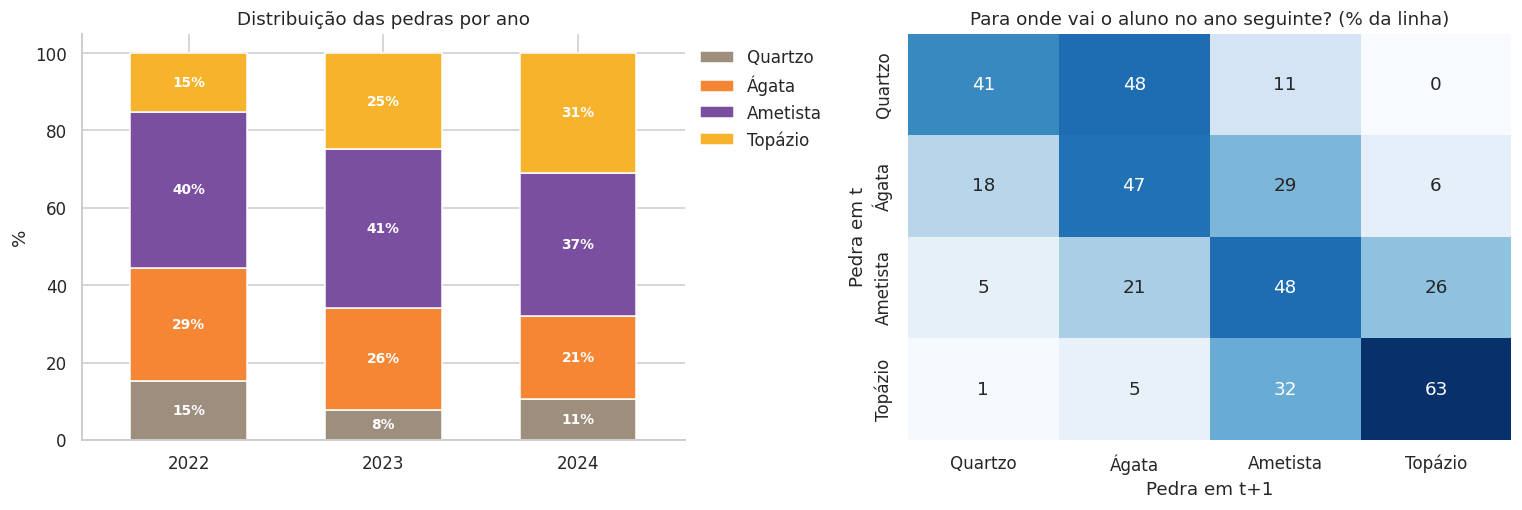

In [14]:
dist = (pd.crosstab(L.ANO, L.PEDRA, normalize="index") * 100)[PEDRA_ORDEM]
display(dist.round(1))
display(L.groupby("PEDRA")[["INDE", "IDA", "IEG", "IPS", "IPP", "IPV", "IAN"]].mean().loc[PEDRA_ORDEM].round(2))

# Transição de pedra do mesmo aluno (t -> t+1)
tr = P.dropna(subset=["PEDRA", "PEDRA_T1"])
trans = (pd.crosstab(tr.PEDRA, tr.PEDRA_T1, normalize="index") * 100).loc[PEDRA_ORDEM, PEDRA_ORDEM]
display(trans.round(0))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
dist.plot(kind="bar", stacked=True, color=[PEDRA_COR[p] for p in PEDRA_ORDEM], ax=ax[0], width=0.6)
for c in ax[0].containers: ax[0].bar_label(c, fmt="%.0f%%", label_type="center", fontsize=9, color="white", fontweight="bold")
ax[0].set(title="Distribuição das pedras por ano", xlabel="", ylabel="%"); ax[0].tick_params(axis="x", rotation=0); ax[0].legend(bbox_to_anchor=(1, 1), frameon=False)
sns.heatmap(trans, annot=True, fmt=".0f", cmap="Blues", ax=ax[1], cbar=False)
ax[1].set(title="Para onde vai o aluno no ano seguinte? (% da linha)", xlabel="Pedra em t+1", ylabel="Pedra em t")
salvar("q10_pedras")

In [15]:
# Coorte fechada: alunos presentes nos três anos
ras = set.intersection(*[set(L[L.ANO == a].RA) for a in (2022, 2023, 2024)])
C = L[L.RA.isin(ras)]
print(f"Coorte presente em 2022, 2023 e 2024: {len(ras)} alunos")
display(C.groupby("ANO")[["INDE", "IDA", "IEG", "IPV", "IAN", "DEFASAGEM"]].mean().round(2))

Coorte presente em 2022, 2023 e 2024: 441 alunos


,INDE,IDA,IEG,IPV,IAN,DEFASAGEM
ANO,,,,,,
2022,7.39,6.69,8.53,7.53,6.67,-0.83
2023,7.35,6.77,8.73,8.07,6.97,-0.68
2024,7.38,6.22,7.97,7.30,8.14,-0.24


**Resposta: há impacto claro na distribuição geral, mas a evolução individual não é linear.**
- **Topázio dobrou**: 15% (2022) → 25% → **31% (2024)**; Quartzo caiu de 15% para 11%.
- Os indicadores escalonam perfeitamente entre pedras (IDA 3,5 Quartzo → 8,2 Topázio; IEG 5,6 → 9,4), confirmando que a classificação é coerente.
- **Mobilidade:** 48% dos alunos Quartzo sobem para Ágata no ano seguinte e 26% dos Ametista viram Topázio. Por outro lado, **32% dos Topázio caem para Ametista** — manter o aluno no topo exige acompanhamento.
- Na **coorte fechada (441 alunos nos 3 anos)**, o INDE ficou estável (≈7,4), mas a **defasagem caiu de −0,83 para −0,24** e o IAN subiu de 6,7 para 8,1: o programa corrige o atraso escolar mesmo quando as notas não sobem.
- Parte da melhora agregada também é explicada pela **saída seletiva de alunos de baixo desempenho** (P11), o que precisa ser considerado ao medir impacto.

## Pergunta 11 — Insights adicionais
### 11.1 Quem sai do programa?

PEDRA,Quartzo,Ágata,Ametista,Topázio
ANO,,,,
2022,40.2,66.0,75.9,90.8
2023,58.3,62.2,80.8,80.6


Retenção geral: {2022: 69.8, 2023: 75.4}


,INDE,IDA,IEG
PERMANECEU,,,
False,6.76,5.70,7.57
True,7.37,6.66,8.60


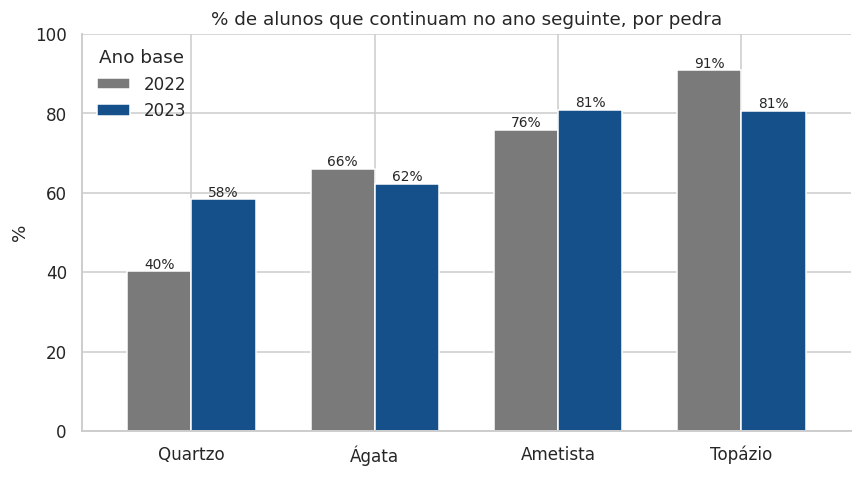

In [16]:
rows = []
for t in (2022, 2023):
    a = L_all[L_all.ANO == t].copy(); a["PERMANECEU"] = a.RA.isin(set(L_all[L_all.ANO == t + 1].RA))
    rows.append(a)
R = pd.concat(rows)
ret = (R.groupby(["ANO", "PEDRA"]).PERMANECEU.mean() * 100).unstack()[PEDRA_ORDEM]
display(ret.round(1)); print("Retenção geral:", (R.groupby("ANO").PERMANECEU.mean() * 100).round(1).to_dict())
display(R.groupby("PERMANECEU")[["INDE", "IDA", "IEG"]].mean().round(2))

ax = ret.T.plot(kind="bar", color=[CINZA, AZUL], figsize=(8, 4.5), width=0.7)
for c in ax.containers: ax.bar_label(c, fmt="%.0f%%", fontsize=9)
ax.set(title="% de alunos que continuam no ano seguinte, por pedra", xlabel="", ylabel="%", ylim=(0, 100)); plt.xticks(rotation=0)
ax.legend(title="Ano base", frameon=False); salvar("q11_retencao")

### 11.2 Tempo de programa, gênero e tipo de escola

In [17]:
display(L.groupby("ANOS_NA_PM")[["INDE", "IDA", "IEG", "IAN"]].mean().round(2).join(L.ANOS_NA_PM.value_counts().rename("n")))
display(L.groupby("GENERO")[["INDE", "IDA", "IEG", "IAA", "IPS"]].mean().round(2))
display(L.groupby("INSTITUICAO_GRUPO")[["INDE", "IDA", "IEG"]].mean().round(2).join(L.INSTITUICAO_GRUPO.value_counts().rename("n")))

,INDE,IDA,IEG,IAN,n
ANOS_NA_PM,,,,,
0,7.33,6.42,8.40,6.95,1116
1,7.32,6.63,8.28,6.67,645
2,7.34,6.42,8.19,7.22,341
3,7.22,6.11,7.85,7.59,437
4,7.06,5.98,8.12,6.94,162
5,6.85,6.10,7.91,7.12,86
6,7.00,6.14,8.16,6.74,59
7,6.91,5.81,8.34,6.75,20


,INDE,IDA,IEG,IAA,IPS
GENERO,,,,,
Feminino,7.34,6.40,8.31,8.57,6.19
Masculino,7.19,6.35,8.13,8.79,6.40


,INDE,IDA,IEG,n
INSTITUICAO_GRUPO,,,,
Não informado,7.21,4.83,5.56,1
Outros/Concluiu EM,7.33,7.38,8.21,14
Privada/Bolsa,7.73,7.00,8.62,378
Pública,7.20,6.28,8.17,2473


**Insights e recomendações:**
1. **Evasão concentrada nos mais vulneráveis.** Só **40% dos alunos Quartzo de 2022 continuaram em 2023**, contra **91% dos Topázio** (na média dos dois ciclos: **47% vs 84%**). Quem sai tem IEG 7,6 vs 8,6 e IDA 5,7 vs 6,7 de quem fica. → Criar um **protocolo de retenção** para Quartzo/Ágata com IEG em queda (contato com a família, tutoria).
2. **Ano de transição de fase é o momento crítico.** A defasagem "nasce" quando o aluno não avança de fase num ano em que a idade exige (142 casos de D = 0 → −1). → O modelo preditivo marca esses alunos com antecedência.
3. **Fases 2-4 (5º ao 9º ano) são o vale acadêmico.** → Reforço de Matemática e Português focado nessas fases.
4. **Bolsistas em escolas privadas** têm INDE 7,7 vs 7,2 da rede pública — o programa de bolsas é um motor de desempenho (atenção ao viés de seleção: bolsas vão para os melhores).
5. **Diferenças de gênero são pequenas** (INDE 7,3 F vs 7,2 M) — não justificam ações específicas.
6. **Qualidade de dados:** padronizar escalas (IPS 2023), manter IPP em todos os anos, não registrar IAA/IEG = 0 para "não avaliado" e separar Fase de Turma no cadastro.

---
➡️ Continua em **`02_modelo_preditivo_risco_defasagem.ipynb`** (Pergunta 9).